In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DataSource: https://www.kaggle.com/datasets/adxie12/horoscopes?select=horoscopes_scraped_2025.csv
# Load dataset (fixing the path)
df = pd.read_csv("../data/horoscope_saved_general.csv")

# Preview dataset
df.head()

,sign,category,date,horoscope
0,aries,general,20241111,"You're usually full of energy, Aries, but toda..."
1,aries,general,20241112,If you've been working toward manifesting extr...
2,aries,general,20241113,"A group of people oriented toward artistic, sp..."
3,aries,general,20241114,You may find today that people are really attr...
4,aries,general,20241115,If your partner acts quickly on his or her pas...


#### Understand the Dataset

In [31]:
display(df.head())

,sign,category,date,horoscope
0,aries,general,20241111,"You're usually full of energy, Aries, but toda..."
1,aries,general,20241112,If you've been working toward manifesting extr...
2,aries,general,20241113,"A group of people oriented toward artistic, sp..."
3,aries,general,20241114,You may find today that people are really attr...
4,aries,general,20241115,If your partner acts quickly on his or her pas...


In [32]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4392 entries, 0 to 4391
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sign       4392 non-null   object
 1   category   4392 non-null   object
 2   date       4392 non-null   int64 
 3   horoscope  4392 non-null   object
dtypes: int64(1), object(3)
memory usage: 137.4+ KB


In [33]:
# Basic statistics
df.describe(include='all')

,sign,category,date,horoscope
count,4392,4392,4.392000e+03,4392
unique,12,1,NaN,4392
top,aries,general,NaN,The annoying restlessness that you experience ...
freq,366,4392,NaN,1
mean,NaN,NaN,2.024925e+07,NaN
std,NaN,NaN,3.296686e+03,NaN
min,NaN,NaN,2.024111e+07,NaN
25%,NaN,NaN,2.025021e+07,NaN
50%,NaN,NaN,2.025051e+07,NaN
75%,NaN,NaN,2.025081e+07,NaN


In [34]:
print(df["date"].min())
print(df["date"].max())

20241110
20251110


#### Convert Dates Properly

In [35]:
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

In [36]:
df.head()

,sign,category,date,horoscope
0,aries,general,2024-11-11,"You're usually full of energy, Aries, but toda..."
1,aries,general,2024-11-12,If you've been working toward manifesting extr...
2,aries,general,2024-11-13,"A group of people oriented toward artistic, sp..."
3,aries,general,2024-11-14,You may find today that people are really attr...
4,aries,general,2024-11-15,If your partner acts quickly on his or her pas...


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4392 entries, 0 to 4391
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   sign       4392 non-null   object        
 1   category   4392 non-null   object        
 2   date       4392 non-null   datetime64[ns]
 3   horoscope  4392 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 137.4+ KB


In [38]:
df["category"].value_counts()

category
general    4392
Name: count, dtype: int64

#### Add Mercury Retrograde Labels

In [39]:
# retrograde periods between 2024-11-10 and 2025-11-10
retrograde_periods = [
    # 2024
    ('2024-11-25', '2024-12-15'),
    # 2025
    ('2025-03-15', '2025-04-07'),
    ('2025-07-18', '2025-08-11'),
    ('2025-11-09', '2025-11-29'),
]

In [40]:
# Function to check if a date comes under retrograde period
def is_retrograde(date):
    for start, end in retrograde_periods:
        if pd.to_datetime(start) <= date <= pd.to_datetime(end):
            return 1
    return 0

In [41]:
df['retrograde'] = df['date'].apply(is_retrograde)

In [42]:
df[['date', 'retrograde']].head(10)

,date,retrograde
0,2024-11-11,0
1,2024-11-12,0
2,2024-11-13,0
3,2024-11-14,0
4,2024-11-15,0
5,2024-11-16,0
6,2024-11-17,0
7,2024-11-18,0
8,2024-11-19,0
9,2024-11-20,0


In [43]:
df["retrograde"].value_counts()

retrograde
0    3528
1     864
Name: count, dtype: int64

#### Clean the Horoscope Text

In [44]:
import re

# text cleaning function
def clean_text(text):
    text = text.lower()
    # remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [45]:
# Apply the function and create a new clean txt column
df['clean_horoscope'] = df['horoscope'].apply(clean_text)

# View results and compare columns
df[['horoscope', 'clean_horoscope']].head()

,horoscope,clean_horoscope
0,"You're usually full of energy, Aries, but toda...",youre usually full of energy aries but today y...
1,If you've been working toward manifesting extr...,if youve been working toward manifesting extra...
2,"A group of people oriented toward artistic, sp...",a group of people oriented toward artistic spi...
3,You may find today that people are really attr...,you may find today that people are really attr...
4,If your partner acts quickly on his or her pas...,if your partner acts quickly on his or her pas...


#### VADER

In [46]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [47]:
# Download VADER lexicon (only once)
# nltk.download('vader_lexicon')

In [48]:
sia = SentimentIntensityAnalyzer()

In [49]:
# testing example
text = "Today you will feel happy and achieve great success."

# get sentiment scores
scores = sia.polarity_scores(text)

print(scores)

{'neg': 0.0, 'neu': 0.343, 'pos': 0.657, 'compound': 0.91}


In [50]:
text2 = "Today will bring difficulties and misunderstandings."

print(sia.polarity_scores(text2))

{'neg': 0.306, 'neu': 0.694, 'pos': 0.0, 'compound': -0.296}


In [51]:
# apply sentiment analysis to clean_text column

# create a new column for sentiment scores
df['sentiment'] = df['clean_horoscope'].apply(lambda x: sia.polarity_scores(x)['compound'])

In [52]:
df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment
0,aries,general,2024-11-11,"You're usually full of energy, Aries, but toda...",0,youre usually full of energy aries but today y...,0.8760
1,aries,general,2024-11-12,If you've been working toward manifesting extr...,0,if youve been working toward manifesting extra...,0.9136
2,aries,general,2024-11-13,"A group of people oriented toward artistic, sp...",0,a group of people oriented toward artistic spi...,0.9509
3,aries,general,2024-11-14,You may find today that people are really attr...,0,you may find today that people are really attr...,0.9020
4,aries,general,2024-11-15,If your partner acts quickly on his or her pas...,0,if your partner acts quickly on his or her pas...,0.9011


##### Convert Sentiment Into Categories

In [53]:
# function to classify sentiment by score
def classify_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

# apply classification function to all rows
df['sentiment_label'] = df['sentiment'].apply(classify_sentiment)

df[['sentiment', 'sentiment_label']].head()

,sentiment,sentiment_label
0,0.8760,positive
1,0.9136,positive
2,0.9509,positive
3,0.9020,positive
4,0.9011,positive


##### Analyze Sentiment Distribution

In [54]:
# count how many of each sentiment type
sentiment_counts = df['sentiment_label'].value_counts()

print(sentiment_counts)


sentiment_label
positive    3637
negative     673
neutral       82
Name: count, dtype: int64


In [55]:
# convert counts to percentage
sentiment_percent = df['sentiment_label'].value_counts(normalize=True) * 100

print(sentiment_percent)

sentiment_label
positive    82.809654
negative    15.323315
neutral      1.867031
Name: proportion, dtype: float64


##### Compare Sentiment (Retrograde vs Normal)

In [56]:
# count how many of each sentiment type group by retrograde
retrograde_sentiment_counts = df.groupby('retrograde')['sentiment_label'].value_counts()

print(retrograde_sentiment_counts)

retrograde  sentiment_label
0           positive           2934
            negative            528
            neutral              66
1           positive            703
            negative            145
            neutral              16
Name: count, dtype: int64


In [57]:
# calculate average sentiment for each group
sentiment_comparison = df.groupby('retrograde')['sentiment'].mean()

print(sentiment_comparison)

retrograde
0    0.572056
1    0.548348
Name: sentiment, dtype: float64


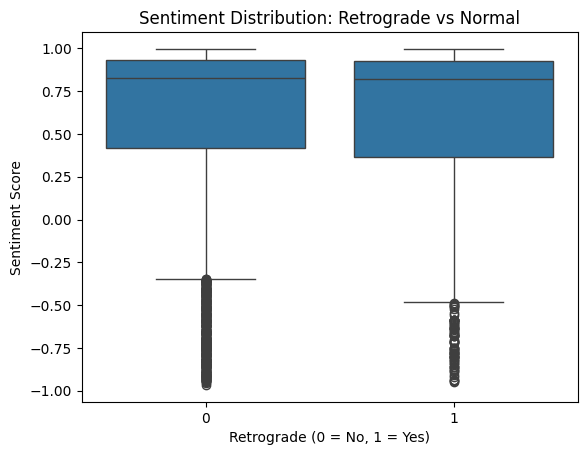

In [58]:
# plot comparison
sns.boxplot(x='retrograde', y='sentiment', data=df)

plt.title("Sentiment Distribution: Retrograde vs Normal")
plt.xlabel("Retrograde (0 = No, 1 = Yes)")
plt.ylabel("Sentiment Score")

plt.show()

#### RoBERTa

In [59]:
from transformers import pipeline
import torch



In [60]:
sentiment_model = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [61]:
sample_text = df["horoscope"].iloc[0]

sentiment_model(sample_text)

[{'label': 'positive', 'score': 0.4869808852672577}]

In [62]:
def get_sentiment(text):
    # limit text length for safety
    # result = sentiment_model(text[:512])[0]
    result =  sentiment_model(text)[0]
    return result["label"], result["score"]

In [63]:
get_sentiment(df["horoscope"].iloc[0])

('positive', 0.4869808852672577)

In [64]:
# testing the process on first 100 rows initially
sample_df = df.head(100).copy()

sample_df["sentiment"] = sample_df["horoscope"].apply(get_sentiment)

sample_df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment,sentiment_label
0,aries,general,2024-11-11,"You're usually full of energy, Aries, but toda...",0,youre usually full of energy aries but today y...,"(positive, 0.4869808852672577)",positive
1,aries,general,2024-11-12,If you've been working toward manifesting extr...,0,if youve been working toward manifesting extra...,"(positive, 0.9288892149925232)",positive
2,aries,general,2024-11-13,"A group of people oriented toward artistic, sp...",0,a group of people oriented toward artistic spi...,"(positive, 0.8904693126678467)",positive
3,aries,general,2024-11-14,You may find today that people are really attr...,0,you may find today that people are really attr...,"(positive, 0.9030788540840149)",positive
4,aries,general,2024-11-15,If your partner acts quickly on his or her pas...,0,if your partner acts quickly on his or her pas...,"(neutral, 0.5961227416992188)",positive


In [65]:
sample_df["sentiment_label"] = sample_df["sentiment"].apply(lambda x: x[0])
sample_df["sentiment_score"] = sample_df["sentiment"].apply(lambda x: x[1])

sample_df.drop(columns=["sentiment"], inplace=True)

sample_df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment_label,sentiment_score
0,aries,general,2024-11-11,"You're usually full of energy, Aries, but toda...",0,youre usually full of energy aries but today y...,positive,0.486981
1,aries,general,2024-11-12,If you've been working toward manifesting extr...,0,if youve been working toward manifesting extra...,positive,0.928889
2,aries,general,2024-11-13,"A group of people oriented toward artistic, sp...",0,a group of people oriented toward artistic spi...,positive,0.890469
3,aries,general,2024-11-14,You may find today that people are really attr...,0,you may find today that people are really attr...,positive,0.903079
4,aries,general,2024-11-15,If your partner acts quickly on his or her pas...,0,if your partner acts quickly on his or her pas...,neutral,0.596123


In [66]:
# clearing these columns before running the model on all rows
df["sentiment_label"] = None
df["sentiment_score"] = None

In [67]:
batch_size = 500

for i in range(0, len(df), batch_size):
    batch = df.iloc[i:i+batch_size].copy()
    
    results = batch["horoscope"].apply(get_sentiment)
    
    df.loc[batch.index, "sentiment_label"] = results.apply(lambda x: x[0])
    df.loc[batch.index, "sentiment_score"] = results.apply(lambda x: x[1])
    
    print(f"Processed: {i} to {i+batch_size}")

Processed: 0 to 500
Processed: 500 to 1000
Processed: 1000 to 1500
Processed: 1500 to 2000
Processed: 2000 to 2500
Processed: 2500 to 3000
Processed: 3000 to 3500
Processed: 3500 to 4000
Processed: 4000 to 4500


Due to computational constraints of transformer-based models, sentiment extraction was performed in batches to optimize memory usage and ensure stability.

In [68]:
def convert_sentiment(label, score):
    if label.lower() == "positive":
        return score
    elif label.lower() == "negative":
        return -score
    else:
        return 0

In [69]:
df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment,sentiment_label,sentiment_score
0,aries,general,2024-11-11,"You're usually full of energy, Aries, but toda...",0,youre usually full of energy aries but today y...,0.8760,positive,0.486981
1,aries,general,2024-11-12,If you've been working toward manifesting extr...,0,if youve been working toward manifesting extra...,0.9136,positive,0.928889
2,aries,general,2024-11-13,"A group of people oriented toward artistic, sp...",0,a group of people oriented toward artistic spi...,0.9509,positive,0.890469
3,aries,general,2024-11-14,You may find today that people are really attr...,0,you may find today that people are really attr...,0.9020,positive,0.903079
4,aries,general,2024-11-15,If your partner acts quickly on his or her pas...,0,if your partner acts quickly on his or her pas...,0.9011,neutral,0.596123


In [70]:
df["sentiment_numeric"] = df.apply(lambda x: convert_sentiment(x["sentiment_label"], x["sentiment_score"]), axis=1)

In [71]:
df.head()

,sign,category,date,horoscope,retrograde,clean_horoscope,sentiment,sentiment_label,sentiment_score,sentiment_numeric
0,aries,general,2024-11-11,"You're usually full of energy, Aries, but toda...",0,youre usually full of energy aries but today y...,0.8760,positive,0.486981,0.486981
1,aries,general,2024-11-12,If you've been working toward manifesting extr...,0,if youve been working toward manifesting extra...,0.9136,positive,0.928889,0.928889
2,aries,general,2024-11-13,"A group of people oriented toward artistic, sp...",0,a group of people oriented toward artistic spi...,0.9509,positive,0.890469,0.890469
3,aries,general,2024-11-14,You may find today that people are really attr...,0,you may find today that people are really attr...,0.9020,positive,0.903079,0.903079
4,aries,general,2024-11-15,If your partner acts quickly on his or her pas...,0,if your partner acts quickly on his or her pas...,0.9011,neutral,0.596123,0.000000


In [72]:
df.groupby("retrograde")["sentiment_numeric"].mean()

retrograde
0    0.336989
1    0.321934
Name: sentiment_numeric, dtype: float64

Horoscopes are slightly more negative during Mercury retrograde but the difference is extremely small.

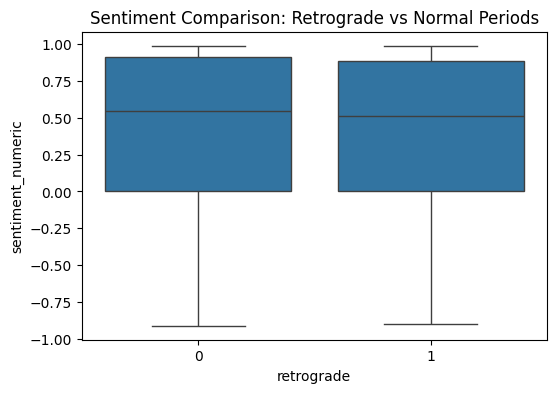

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x="retrograde", y="sentiment_numeric", data=df)
plt.title("Sentiment Comparison: Retrograde vs Normal Periods")
plt.show()

#### T-Test

In [79]:
from scipy.stats import ttest_ind

# Split data into two groups
retrograde_sentiment = df[df["retrograde"] == 1]["sentiment_numeric"]
normal_sentiment = df[df["retrograde"] == 0]["sentiment_numeric"]

# Perform independent t-test
t_stat, p_value = ttest_ind(
    retrograde_sentiment,
    normal_sentiment,
    equal_var=False  # Welch's t-test (recommended)
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

T-statistic: -0.6800
P-value: 0.496624


In [81]:
alpha = 0.05

if p_value < alpha:
    print("Result: Statistically significant difference.")
    print("Reject the null hypothesis.")
else:
    print("Result: No statistically significant difference.")
    print("Fail to reject the null hypothesis.")

Result: No statistically significant difference.
Fail to reject the null hypothesis.


In [75]:
daily_sentiment = (
    df.groupby("date")["sentiment_numeric"]
      .mean()
      .reset_index()
)

<Axes: xlabel='date', ylabel='sentiment_numeric'>

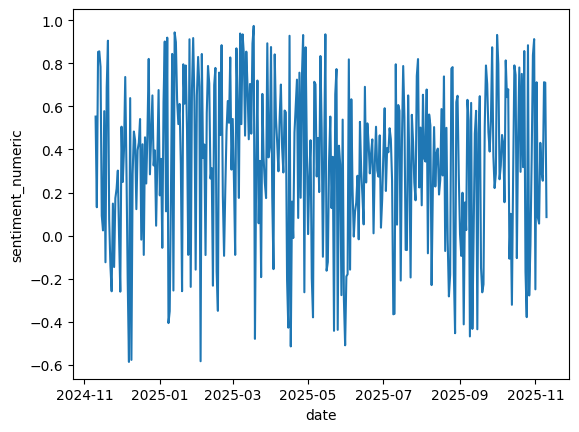

In [76]:
sns.lineplot(
    data=daily_sentiment,
    x="date",
    y="sentiment_numeric"
)

In [77]:
df["month"] = df["date"].dt.month

In [78]:
monthly = (
    df.groupby("month")["sentiment_numeric"]
      .mean()
)